# MSBA 265 - Foundational Module 1: Exploratory Data Analysis & Visual Outlier Audits
** Author :** Visiting Instructor Shyla Solis
** Course :** MSBA 265 - Business Analytics Topics
** Dataset :** French Motor Third Party Liability Claims ( OpenML ID: 41214)

---
### Business Problem Overview
In property and casualty insurance, policy pricing depends on understanding risk exposure, driver age, and population density. Before building predictive loss models or business strategy dashboards, we must inspect raw feature data types, construct a domain - specific Business Data Dictionary, plot feature distributions, evaluate univariate skewness, and visually diagnose extreme outliers.

In [29]:
import os # deal with file paths and directories
import pandas as pd # for handling tabular data
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for creating static, animated, and interactive visualizations
import seaborn as sns # for making statistical graphics in Python

In [30]:
# Set Visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid') # Set the plotting style for clean presentation graphics
plt.rcParams['font.sans-serif'] = 'DejaVu Sans' # Set the font for plots to DejaVu Sans
plt.rcParams['font.size'] = 10 # Set the default font size for plots
pd.set_option('display.max_columns', 20) # Set the maximum number of columns to display in pandas DataFrames

In [31]:
# Load dataset
data_path = os.path.join("..", 'data', 'raw_business_data.csv')     # Define the path to the raw business data file
if not os.path.exists(data_path):       # Check if the file exists at the specified path
    data_path = os.path.join("data", 'raw_business_data.csv')
df = pd.read_csv(data_path)     # Read the CSV file into a pandas DataFrame
print(f"[+] Loaded Dataset Shape :{df.shape[0] : ,} rows x {df.shape[1]} columns")   # Print the shape of the loaded dataset

#  Render interactive HTML table head to display the first 10 rows of the DataFrame
df.head(10)

[+] Loaded Dataset Shape : 678,013 rows x 12 columns


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


In [32]:
print (" ================================================== ") # Print a separator line for visual clarity
print (" 1. STRUCTURAL DATA TYPES & NULLS ") # Print the section title for structural data types and null values
print (" ================================================== ")
df.info() # Display information about the DataFrame, including data types and null counts

 1. STRUCTURAL DATA TYPES & NULLS 
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [33]:
print ("\n ================================================== ") # Print a separator line for visual clarity
print (" 2. SUMMARY STATISTICS ( NUMERICAL ) ") # Print the section title for summary statistics of numerical columns
print (" ================================================== ")
df.describe().T # Display summary statistics for the numerical columns of the DataFrame, transposed for better readability


 2. SUMMARY STATISTICS ( NUMERICAL ) 


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [34]:
business_definitions = {
    "IDpol": ("Policy ID", "Key ID", "Unique policy identification key assigned to contract."), # Unique identifier for each policy
    "ClaimNb": ("Claim Count", "Count", "Total insurance claims filed during policy coverage period."),
    "Exposure": ("Risk Exposure", "Years (0.0-1.0)", "Fraction of year policy was active (e.g., 0.50 = 6 months coverage)."),
    "Area": ("Area Risk Code", "Ordinal Category", "Geographic risk code of policyholder address (A = rual, F =urban)."),
    "VehPower": ("Engine Power", "Tax HP", "Fiscal power rating category of the vehicle engine."),
    "VehAge": ("Vehicle Age", "Years", "Age of the insured vehicle in years."),
    "DrivAge": ("Driver Age", "Years", "Age of primary insured driver in years."),
    "BonusMalus": ("Claim History Index", "Index Score(50-350)","Regulatory driver risk score (<100: safe discount; >100: claim surcharge)."),
    "VehBrand": ("Brand Class", "Category Code", "Anonymized vehicle manufacturer/brand classification code."),
    "VehGas": ("Fuel Type", "Binary Class","Engine fuel type used (Diesel vs. Regular/Gasoline)."),
    "Density": ("Population Density", "People / km2", "Population density of policyholder's municipality."),
    "Region": ("Administrative Region", "Region Code", "French administrative region code corresponding to residency location.")
}


In [35]:
dict_list = [] # Initialize an empty list to store the data dictionary entries
for col in df.columns:
    label, unit, definition = business_definitions.get(col, (col,"N/A","No business definition provided."))
    dict_list.append({
        "Feature Name": col,
        "Business Label": label,
        "Data Type": str(df[col].dtype),
        "Unit": unit,
        "Null Count": df[col].isnull().sum(),
        "Unique Values": df[col].nunique(),
        "Business Definition": definition
        })
dict_df = pd.DataFrame(dict_list)
display(dict_df)

,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,IDpol,Policy ID,float64,Key ID,0,678013,Unique policy identification key assigned to c...
1,ClaimNb,Claim Count,int64,Count,0,11,Total insurance claims filed during policy cov...
2,Exposure,Risk Exposure,float64,Years (0.0-1.0),0,181,"Fraction of year policy was active (e.g., 0.50..."
3,Area,Area Risk Code,str,Ordinal Category,0,6,Geographic risk code of policyholder address (...
4,VehPower,Engine Power,int64,Tax HP,0,12,Fiscal power rating category of the vehicle en...
5,VehAge,Vehicle Age,int64,Years,0,78,Age of the insured vehicle in years.
6,DrivAge,Driver Age,int64,Years,0,83,Age of primary insured driver in years.
7,BonusMalus,Claim History Index,int64,Index Score(50-350),0,115,Regulatory driver risk score (<100: safe disco...
8,VehBrand,Brand Class,str,Category Code,0,11,Anonymized vehicle manufacturer/brand classifi...
9,VehGas,Fuel Type,str,Binary Class,0,2,Engine fuel type used (Diesel vs. Regular/Gaso...


In [36]:
reports_dir = os.path.join("..","reports")
os.makedirs(reports_dir, exist_ok=True)
dict_path = os.path.join(reports_dir, "data_dictionary.csv")
dict_df.to_csv(dict_path, index=False)
print(f"\n[+] Sucessfully exported Business Data Dictionary artifact to :{dict_path}")


[+] Sucessfully exported Business Data Dictionary artifact to :..\reports\data_dictionary.csv


In [37]:
print (" ================================================== ")
print (" UNIVARIATE SKEWNESS DIAGNOSTICS ")
print (" ================================================== ")

numeric_df = df. select_dtypes ( include =[ np. number ])
skewness_series = numeric_df . skew (). sort_values ( ascending = False )

skew_summary = pd. DataFrame ({
     " Feature ": skewness_series .index ,
     " Skewness Coefficient ": skewness_series .values ,
     " Diagnosis ": [" Extremely Right - Skewed " if s > 3.0 else " Moderately Skewed " if
        abs(s) > 1.0 else " Unskewed / Symmetric " for s in skewness_series . values ],
     " Action Required ": ["Log / Box -Cox Transform " if abs(s) > 1.0 else " StandardScaler Sufficient " for s in skewness_series . values ]
})
display ( skew_summary )

 UNIVARIATE SKEWNESS DIAGNOSTICS 


,Feature,Skewness Coefficient,Diagnosis,Action Required
0,ClaimNb,5.599613,Extremely Right - Skewed,Log / Box -Cox Transform
1,Density,4.651421,Extremely Right - Skewed,Log / Box -Cox Transform
2,BonusMalus,1.728934,Moderately Skewed,Log / Box -Cox Transform
3,VehPower,1.171344,Moderately Skewed,Log / Box -Cox Transform
4,VehAge,1.147989,Moderately Skewed,Log / Box -Cox Transform
5,DrivAge,0.435759,Unskewed / Symmetric,StandardScaler Sufficient
6,IDpol,0.237890,Unskewed / Symmetric,StandardScaler Sufficient
7,Exposure,0.085318,Unskewed / Symmetric,StandardScaler Sufficient


In [38]:
print (" ================================================== ")
print (" PEARSON MULTICOLLINEARITY AUDIT ")
print (" ================================================== ")

corr_matrix = numeric_df.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    high_corr_features =upper_tri.index[upper_tri[col] >=0.85].tolist()
    for feat in high_corr_features:
        val = upper_tri.loc[feat, col]
        high_corr_pairs.append({
           "Feature 1":feat,
           "Feature 2":col,
           "Pearson Correlation (|r|)": round(val,4),
           "Status": "ACTION REQUIRED: Severe Multicollinearity"
        })
if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs))
else:
    print("[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.")

 PEARSON MULTICOLLINEARITY AUDIT 
[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.


In [39]:
# View the entire VehPower column
df["VehPower"]

0         5
1         5
2         6
3         7
4         7
         ..
678008    4
678009    4
678010    6
678011    4
678012    7
Name: VehPower, Length: 678013, dtype: int64

In [ ]:
df["VehPower"].unique()

array([ 5,  6,  7,  4,  9, 15,  8, 10, 12, 11, 14, 13])

In [41]:
df["VehPower"].value_counts().sort_index()

VehPower
4     115349
5     124821
6     148976
7     145401
8      46956
9      30085
10     31354
11     18352
12      8214
13      3229
14      2350
15      2926
Name: count, dtype: int64

In [42]:
df["VehPower"].describe()

count    678013.000000
mean          6.454631
std           2.050906
min           4.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          15.000000
Name: VehPower, dtype: float64

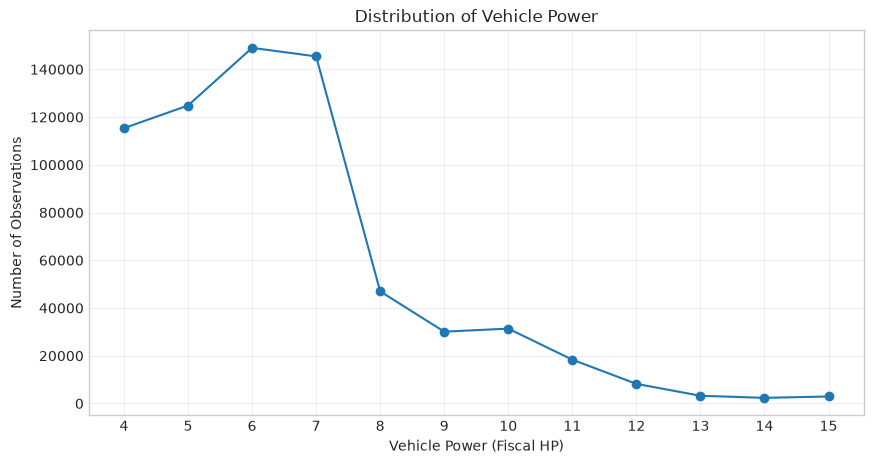

In [44]:
import matplotlib.pyplot as plt

vehpower_counts = df["VehPower"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(
    vehpower_counts.index,
    vehpower_counts.values,
    marker="o"
)

plt.xlabel("Vehicle Power (Fiscal HP)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Vehicle Power")
plt.xticks(vehpower_counts.index)
plt.grid(alpha=0.3)

plt.show()

In [45]:
df["ClaimFrequency"] = df["ClaimNb"] / df["Exposure"]

vehpower_claim = (
    df.groupby("VehPower")["ClaimFrequency"]
      .mean()
      .reset_index()
)

vehpower_claim

,VehPower,ClaimFrequency
0,4,0.276456
1,5,0.299052
2,6,0.255648
3,7,0.247424
4,8,0.146438
5,9,0.330009
6,10,0.331983
7,11,0.255552
8,12,0.259646
9,13,0.106512
